#  Salary Prediction - Machine Learning Model Training & Evaluation
**Project:** Salary Prediction Model  
**Target Level:** Internship / Entry-Level ML Portfolio  
**Algorithms Evaluated:** Linear Regression, Decision Tree, Random Forest, XGBoost  

---
###  Workflow Overview:
1. **Data Loading & Preprocessing** (Handling null values, duplicates, and feature scaling/encoding)
2. **Train-Test Split** (80% Train / 20% Test)
3. **Model Training & Comparison** (Linear Regression, Decision Tree, Random Forest, XGBoost)
4. **Hyperparameter Tuning** (Random Forest & XGBoost)
5. **Model Evaluation & Visualization** (R² Score, RMSE, MAE, Feature Importances, Actual vs Predicted)
6. **Save Production Artifacts** (`best_model.pkl`, `metrics.json`)


## 1. Imports & Setup

In [1]:
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load & Clean Dataset

In [2]:
file_path = os.path.join('..', 'dataset', 'Salary Data.csv') if os.path.exists('../dataset/Salary Data.csv') else os.path.join('dataset', 'Salary Data.csv')
df = pd.read_csv(file_path)

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print(f"Cleaned Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Cleaned Dataset Shape: 324 rows x 6 columns


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## 3. Train-Test Split & Preprocessing Pipeline

In [3]:
X = df.drop(columns=['Salary'])
y = df['Salary']

num_cols = ['Age', 'Years of Experience']
cat_cols = ['Gender', 'Education Level', 'Job Title']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")


Training Samples: 259 | Testing Samples: 65


## 4. Train & Benchmark Selected Models

In [4]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, verbosity=0)
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    
    fitted_pipelines[name] = pipe
    results.append({
        'Model': name,
        'Train R2': round(train_r2, 4),
        'Test R2': round(test_r2, 4),
        'MAE ($)': round(mae, 2),
        'RMSE ($)': round(rmse, 2),
        '5-Fold CV Mean R2': round(cv_scores.mean(), 4)
    })

results_df = pd.DataFrame(results).sort_values(by='Test R2', ascending=False)
display(results_df)


,Model,Train R2,Test R2,MAE ($),RMSE ($),5-Fold CV Mean R2
2,Random Forest,0.9833,0.8764,10588.21,15280.53,0.8774
0,Linear Regression,0.9866,0.8670,12303.90,15851.15,0.8257
3,XGBoost,0.9956,0.8392,11533.67,17431.45,0.8795
1,Decision Tree,0.9984,0.8323,12000.00,17802.33,0.8373


## 5. Hyperparameter Tuning (Random Forest & XGBoost)

In [5]:
rf_param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5]
}

xgb_param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1, 0.2]
}

rf_pipe = Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=RANDOM_STATE))])
rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)

xgb_pipe = Pipeline([('preprocessor', preprocessor), ('model', XGBRegressor(random_state=RANDOM_STATE, verbosity=0))])
xgb_grid = GridSearchCV(xgb_pipe, xgb_param_grid, cv=5, scoring='r2', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"Best Random Forest CV R2: {rf_grid.best_score_:.4f}")
print(f"Best XGBoost CV R2: {xgb_grid.best_score_:.4f}")


Best Random Forest CV R2: 0.8784
Best XGBoost CV R2: 0.8852


## 6. Final Model Evaluation & Comparison

In [6]:
final_models = {
    'Tuned Random Forest': rf_grid.best_estimator_,
    'Tuned XGBoost': xgb_grid.best_estimator_
}

final_results = results.copy()

for name, pipe in final_models.items():
    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    
    fitted_pipelines[name] = pipe
    final_results.append({
        'Model': name,
        'Train R2': round(train_r2, 4),
        'Test R2': round(test_r2, 4),
        'MAE ($)': round(mae, 2),
        'RMSE ($)': round(rmse, 2),
        '5-Fold CV Mean R2': round(cv_scores.mean(), 4)
    })

final_df = pd.DataFrame(final_results).sort_values(by='Test R2', ascending=False).reset_index(drop=True)
print("=== FINAL MODEL PERFORMANCE SUMMARY ===")
display(final_df)

best_model_name = final_df.iloc[0]['Model']
best_pipeline = fitted_pipelines[best_model_name]

print("Best Model Selected:", best_model_name)


=== FINAL MODEL PERFORMANCE SUMMARY ===


,Model,Train R2,Test R2,MAE ($),RMSE ($),5-Fold CV Mean R2
0,Tuned XGBoost,0.9642,0.8872,10450.50,14597.43,0.8852
1,Tuned Random Forest,0.9779,0.8811,10498.53,14988.87,0.8784
2,Random Forest,0.9833,0.8764,10588.21,15280.53,0.8774
3,Linear Regression,0.9866,0.8670,12303.90,15851.15,0.8257
4,XGBoost,0.9956,0.8392,11533.67,17431.45,0.8795
5,Decision Tree,0.9984,0.8323,12000.00,17802.33,0.8373


Best Model Selected: Tuned XGBoost


## 7. Model Interpretation & Visualizations

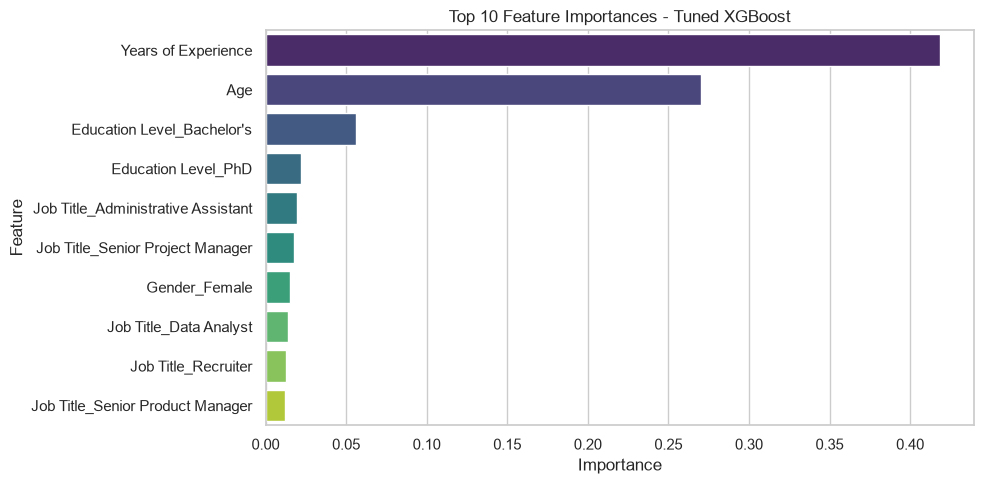

In [7]:
prep = best_pipeline.named_steps['preprocessor']
model_step = best_pipeline.named_steps['model']

cat_encoded_names = prep.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_features = num_cols + cat_encoded_names

if hasattr(model_step, 'feature_importances_'):
    fi_df = pd.DataFrame({
        'Feature': all_features,
        'Importance': model_step.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(10)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=fi_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
    plt.tight_layout()
    plt.show()


### Actual vs. Predicted & Residual Plot

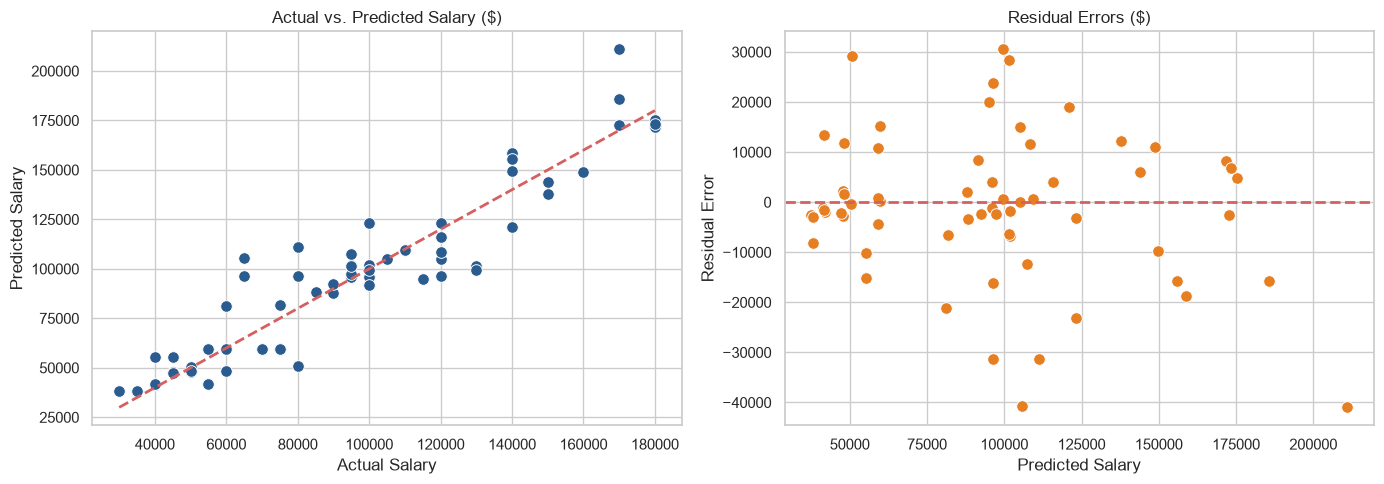

In [8]:
y_pred_best = best_pipeline.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=y_pred_best, ax=axes[0], color='#2b5c8f', s=70)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Salary ($)')
axes[0].set_xlabel('Actual Salary')
axes[0].set_ylabel('Predicted Salary')

sns.scatterplot(x=y_pred_best, y=residuals, ax=axes[1], color='#e67e22', s=70)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_title('Residual Errors ($)')
axes[1].set_xlabel('Predicted Salary')
axes[1].set_ylabel('Residual Error')

plt.tight_layout()
plt.show()


## 8. Save Best Model & Metrics

In [9]:
model_path = os.path.join('..', 'models', 'best_model.pkl') if os.path.exists('../models') else os.path.join('models', 'best_model.pkl')
metrics_path = os.path.join('..', 'models', 'metrics.json') if os.path.exists('../models') else os.path.join('models', 'metrics.json')

joblib.dump(best_pipeline, model_path)

best_row = final_df.iloc[0]
metrics_summary = {
    'model_name': str(best_row['Model']),
    'train_r2': float(best_row['Train R2']),
    'test_r2': float(best_row['Test R2']),
    'mae': float(best_row['MAE ($)']),
    'rmse': float(best_row['RMSE ($)']),
    'cv_mean_r2': float(best_row['5-Fold CV Mean R2'])
}

with open(metrics_path, 'w') as f:
    json.dump(metrics_summary, f, indent=4)

print("Saved Production Artifacts:")
print(f" - Model File: {model_path}")
print(f" - Metrics File: {metrics_path}")


Saved Production Artifacts:
 - Model File: ..\models\best_model.pkl
 - Metrics File: ..\models\metrics.json
